In [1]:
cd ../..

/home/mrefoyo/Projects/Multi-SpaCE


In [2]:
import os
import pickle
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from experiments.evaluation.evaluation_utils import (
    load_dataset_for_eval, 
    calculate_metrics_for_dataset,
    calculate_metrics_for_dataset_mp,
    generate_critical_difference_diagrams,
    generate_wilcoxon_holm_tables,
)

print(tf.__version__)

2026-05-05 20:26:08.063770: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 20:26:08.199262: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 20:26:08.216002: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-05 20:26:08.216020: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above

2.10.1


In [3]:
# DATASETS = ['CBF', 'chinatown', 'coffee', 'gunpoint', 'ECG200']
DATASETS = [
    "BasicMotions", 
    "NATOPS", 
    "UWaveGestureLibrary",
    'ArticularyWordRecognition', 'Cricket',
    'Epilepsy', 
    'PenDigits', 
    'PEMS-SF', 
    'RacketSports', 'SelfRegulationSCP1'
]
DATASETS = [
    "BasicMotions", 
    "NATOPS", 
    "UWaveGestureLibrary",
    'ArticularyWordRecognition', # 'Cricket',
    'Epilepsy', 
    'PenDigits', 
    # 'PEMS-SF', 
    'RacketSports', 'SelfRegulationSCP1'
]


MO_UTILITY = np.array([0.1, 0.4*0.7, 0.6*0.7, 0.2])
model_to_explain = "inceptiontime_noscaling"
scaling = "none"
osc_names = {"AE": "ae_basic_train", "IF": "if_basic_train", "LOF": "lof_basic_train"}
methods = {
    # Comparison between single objective and multi objective ordered by same weights
    "574aca0df70f6f6d3ceac2fbf11faa9dc1b3b8ce": "Multi-SpaCE Global",
    "v2_f3f682b91a67a3c7bd162bc42643e1ae656743cf": "New",
}

# Get results

In [4]:
PENALIZATION_QUANTILES = ['none', 0.75, 0.95, 1.0]
PENALIZE_INVALID = True

# Data and aux data dict
data_dict = {}
models_dict = {}
outlier_calculators_dict = {}
possible_nuns_dict = {}
desired_classes_dict = {}
original_classes_dict = {}

# Results dicts keyed by penalization choice
mean_results_dict_all = {}
methods_cfs_dict_all = {}
results_all_datasets_df_all = {}
common_test_indexes_dict_all = {}

# Iterate through datasets
for dataset in DATASETS:
    print(f'Calculating metrics for {dataset}')
    data_tuple, original_classes, model, outlier_calculators, possible_nuns, desired_classes = load_dataset_for_eval(dataset, model_to_explain, osc_names, scaling=scaling)
    data_dict[dataset] = data_tuple
    models_dict[dataset] = model
    outlier_calculators_dict[dataset] = outlier_calculators
    possible_nuns_dict[dataset] = possible_nuns
    desired_classes_dict[dataset] = desired_classes
    original_classes_dict[dataset] = original_classes

    dataset_results = calculate_metrics_for_dataset(
        dataset, methods, model_to_explain,
        data_tuple, original_classes, model, outlier_calculators, possible_nuns,
        mo_weights=MO_UTILITY,
        penalize_invalid=PENALIZE_INVALID,
        penalization_quantile=PENALIZATION_QUANTILES,
    )

    mean_results_dict_all[dataset] = {key: result['mean_std_df'] for key, result in dataset_results.items()}
    methods_cfs_dict_all[dataset] = {key: result['method_cfs_dataset'] for key, result in dataset_results.items()}
    results_all_datasets_df_all[dataset] = {key: result['results_df'] for key, result in dataset_results.items()}
    common_test_indexes_dict_all[dataset] = {key: result['common_test_indexes'] for key, result in dataset_results.items()}



Calculating metrics for BasicMotions


2026-05-05 20:26:12.744271: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-05 20:26:12.747580: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-05 20:26:12.751408: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-05 20:26:12.751546: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-05-05 20:26:12.751654: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not lo

574aca0df70f6f6d3ceac2fbf11faa9dc1b3b8ce


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:04<00:00,  9.03it/s]


multisubspace_v2_ip_global_ec_mutation/v2_f3f682b91a67a3c7bd162bc42643e1ae656743cf


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.46it/s]


Calculating metrics for SelfRegulationSCP1
574aca0df70f6f6d3ceac2fbf11faa9dc1b3b8ce


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  5.94it/s]


multisubspace_v2_ip_global_ec_mutation/v2_f3f682b91a67a3c7bd162bc42643e1ae656743cf


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.75it/s]


In [6]:
from IPython.display import display

selected_penalization_key = 'none'

mean_results_dict = {
    dataset: mean_results_dict_all[dataset][selected_penalization_key]
    for dataset in DATASETS
}
methods_cfs_dict = {
    dataset: methods_cfs_dict_all[dataset][selected_penalization_key]
    for dataset in DATASETS
}
common_test_indexes_dict = {
    dataset: common_test_indexes_dict_all[dataset][selected_penalization_key]
    for dataset in DATASETS
}
results_all_datasets_df = pd.concat(
    [results_all_datasets_df_all[dataset][selected_penalization_key] for dataset in DATASETS],
    ignore_index=True,
)

print(f'Selected penalization key: {selected_penalization_key}')



Selected penalization key: none


## Instance coverage diagnostics

Use these tables to inspect how many evaluated instances exist per dataset and method, and how they relate to the common test indexes used in the comparison.

## Raw metrics

In [7]:
from IPython.display import display
for dataset in DATASETS:
    print(dataset)
    display(mean_results_dict[dataset])

BasicMotions


,method,ii,nchanges,sparsity,L1,L2,proba,pred_class,target_class,valid,...,AE_IOS,IF_IOS,LOF_IOS,subsequences,subsequences %,(sparsity + subsequences %) / 2,times,best cf index,selected utility score,IoN
0,Multi-SpaCE Global,19.5 ± 11.69,111.8 ± 55.56,0.19 ± 0.09,644.6 ± 615.14,67.67 ± 49.39,0.72 ± 0.14,2.48 ± 0.51,2.48 ± 0.51,1.0 ± 0.0,...,0.03 ± 0.04,0.0 ± 0.01,0.0 ± 0.0,4.95 ± 4.76,0.02 ± 0.02,0.26 ± 0.06,6.28 ± 0.24,15.05 ± 18.96,-0.13 ± 0.05,0.22 ± 0.05
1,New,19.5 ± 11.69,116.72 ± 60.61,0.19 ± 0.1,680.72 ± 659.96,69.39 ± 50.98,0.8 ± 0.15,2.48 ± 0.51,2.48 ± 0.51,1.0 ± 0.0,...,0.03 ± 0.04,0.0 ± 0.01,0.0 ± 0.0,3.02 ± 2.6,0.01 ± 0.01,0.25 ± 0.06,9.9 ± 0.94,44.62 ± 29.98,-0.11 ± 0.05,0.24 ± 0.05


NATOPS


,method,ii,nchanges,sparsity,L1,L2,proba,pred_class,target_class,valid,...,AE_IOS,IF_IOS,LOF_IOS,subsequences,subsequences %,(sparsity + subsequences %) / 2,times,best cf index,selected utility score,IoN
0,Multi-SpaCE Global,87.18 ± 53.72,133.67 ± 134.06,0.11 ± 0.11,93.02 ± 103.04,8.22 ± 6.33,0.9 ± 0.09,2.31 ± 1.81,2.31 ± 1.81,1.0 ± 0.0,...,0.07 ± 0.09,0.01 ± 0.02,0.01 ± 0.02,9.63 ± 9.16,0.02 ± 0.01,0.22 ± 0.1,9.03 ± 0.48,25.16 ± 30.24,-0.09 ± 0.07,0.28 ± 0.07
1,New,87.18 ± 53.72,102.55 ± 87.15,0.08 ± 0.07,84.16 ± 89.34,8.1 ± 6.16,0.91 ± 0.1,2.31 ± 1.81,2.31 ± 1.81,1.0 ± 0.0,...,0.07 ± 0.08,0.0 ± 0.01,0.01 ± 0.02,7.45 ± 5.76,0.01 ± 0.01,0.2 ± 0.07,13.27 ± 1.42,36.13 ± 29.53,-0.08 ± 0.05,0.29 ± 0.05


UWaveGestureLibrary


...

,method,ii,nchanges,sparsity,L1,L2,proba,pred_class,target_class,valid,...,AE_IOS,IF_IOS,LOF_IOS,subsequences,subsequences %,(sparsity + subsequences %) / 2,times,best cf index,selected utility score,IoN
0,Multi-SpaCE Global,1775.95 ± 1043.05,4.51 ± 2.96,0.28 ± 0.19,77.83 ± 47.11,43.5 ± 19.06,0.93 ± 0.09,4.7 ± 2.99,4.7 ± 2.99,1.0 ± 0.0,...,0.11 ± 0.13,0.02 ± 0.03,0.14 ± 0.17,1.69 ± 0.72,0.21 ± 0.09,0.47 ± 0.11,5.64 ± 0.35,48.61 ± 40.07,-0.27 ± 0.06,0.21 ± 0.07
1,New,1775.95 ± 1043.05,4.41 ± 2.78,0.28 ± 0.17,75.01 ± 45.79,42.74 ± 19.28,0.93 ± 0.09,4.7 ± 2.99,4.7 ± 2.99,1.0 ± 0.0,...,0.11 ± 0.13,0.03 ± 0.04,0.14 ± 0.17,1.85 ± 0.82,0.23 ± 0.1,0.48 ± 0.11,8.11 ± 0.71,33.67 ± 31.59,-0.27 ± 0.06,0.2 ± 0.06


RacketSports


,method,ii,nchanges,sparsity,L1,L2,proba,pred_class,target_class,valid,...,AE_IOS,IF_IOS,LOF_IOS,subsequences,subsequences %,(sparsity + subsequences %) / 2,times,best cf index,selected utility score,IoN
0,Multi-SpaCE Global,74.15 ± 41.52,22.16 ± 13.26,0.12 ± 0.07,188.09 ± 93.99,50.11 ± 14.14,0.77 ± 0.13,0.85 ± 1.07,0.85 ± 1.07,1.0 ± 0.0,...,0.02 ± 0.03,0.01 ± 0.02,0.0 ± 0.01,2.85 ± 1.45,0.03 ± 0.02,0.27 ± 0.06,7.61 ± 0.3,15.51 ± 25.82,-0.13 ± 0.04,0.26 ± 0.04
1,New,74.15 ± 41.52,21.69 ± 11.94,0.12 ± 0.07,185.08 ± 84.57,50.12 ± 13.42,0.81 ± 0.12,0.85 ± 1.07,0.85 ± 1.07,1.0 ± 0.0,...,0.02 ± 0.03,0.01 ± 0.02,0.01 ± 0.01,2.93 ± 1.27,0.03 ± 0.01,0.27 ± 0.05,9.78 ± 1.31,35.11 ± 30.49,-0.13 ± 0.04,0.26 ± 0.04


SelfRegulationSCP1


,method,ii,nchanges,sparsity,L1,L2,proba,pred_class,target_class,valid,...,AE_IOS,IF_IOS,LOF_IOS,subsequences,subsequences %,(sparsity + subsequences %) / 2,times,best cf index,selected utility score,IoN
0,Multi-SpaCE Global,145.63 ± 82.65,332.55 ± 358.73,0.06 ± 0.07,5118.56 ± 5683.82,288.78 ± 216.57,0.81 ± 0.13,0.41 ± 0.49,0.41 ± 0.49,1.0 ± 0.0,...,0.04 ± 0.06,0.0 ± 0.0,0.0 ± 0.0,17.38 ± 17.45,0.01 ± 0.01,0.16 ± 0.07,524.5 ± 240.22,18.84 ± 19.85,-0.05 ± 0.06,0.24 ± 0.06
1,New,145.63 ± 82.65,188.48 ± 175.51,0.04 ± 0.03,3328.14 ± 3078.97,252.5 ± 156.71,0.89 ± 0.08,0.41 ± 0.49,0.41 ± 0.49,1.0 ± 0.0,...,0.03 ± 0.04,0.0 ± 0.0,0.0 ± 0.0,9.19 ± 8.52,0.0 ± 0.0,0.13 ± 0.04,218.39 ± 55.74,47.01 ± 31.91,-0.02 ± 0.03,0.27 ± 0.04


In [8]:
columns = ["sparsity", "L2", "proba", "valid", "AE_OS", "IF_OS", "LOF_OS", "subsequences", '(sparsity + subsequences %) / 2', "times"]
for dataset in DATASETS:
    print(dataset)
    display(mean_results_dict[dataset].set_index("method").sort_index()[columns])

BasicMotions


,sparsity,L2,proba,valid,AE_OS,IF_OS,LOF_OS,subsequences,(sparsity + subsequences %) / 2,times
method,,,,,,,,,,
Multi-SpaCE Global,0.19 ± 0.09,67.67 ± 49.39,0.72 ± 0.14,1.0 ± 0.0,0.34 ± 0.21,0.27 ± 0.22,0.04 ± 0.08,4.95 ± 4.76,0.26 ± 0.06,6.28 ± 0.24
New,0.19 ± 0.1,69.39 ± 50.98,0.8 ± 0.15,1.0 ± 0.0,0.34 ± 0.21,0.27 ± 0.21,0.03 ± 0.06,3.02 ± 2.6,0.25 ± 0.06,9.9 ± 0.94


NATOPS


,sparsity,L2,proba,valid,AE_OS,IF_OS,LOF_OS,subsequences,(sparsity + subsequences %) / 2,times
method,,,,,,,,,,
Multi-SpaCE Global,0.11 ± 0.11,8.22 ± 6.33,0.9 ± 0.09,1.0 ± 0.0,0.62 ± 0.21,0.29 ± 0.17,0.21 ± 0.19,9.63 ± 9.16,0.22 ± 0.1,9.03 ± 0.48
New,0.08 ± 0.07,8.1 ± 6.16,0.91 ± 0.1,1.0 ± 0.0,0.62 ± 0.22,0.29 ± 0.16,0.21 ± 0.19,7.45 ± 5.76,0.2 ± 0.07,13.27 ± 1.42


UWaveGestureLibrary


...

,sparsity,L2,proba,valid,AE_OS,IF_OS,LOF_OS,subsequences,(sparsity + subsequences %) / 2,times
method,,,,,,,,,,
Multi-SpaCE Global,0.28 ± 0.19,43.5 ± 19.06,0.93 ± 0.09,1.0 ± 0.0,0.27 ± 0.12,0.32 ± 0.13,0.23 ± 0.18,1.69 ± 0.72,0.47 ± 0.11,5.64 ± 0.35
New,0.28 ± 0.17,42.74 ± 19.28,0.93 ± 0.09,1.0 ± 0.0,0.27 ± 0.12,0.32 ± 0.13,0.23 ± 0.18,1.85 ± 0.82,0.48 ± 0.11,8.11 ± 0.71


RacketSports


,sparsity,L2,proba,valid,AE_OS,IF_OS,LOF_OS,subsequences,(sparsity + subsequences %) / 2,times
method,,,,,,,,,,
Multi-SpaCE Global,0.12 ± 0.07,50.11 ± 14.14,0.77 ± 0.13,1.0 ± 0.0,0.7 ± 0.14,0.33 ± 0.16,0.12 ± 0.1,2.85 ± 1.45,0.27 ± 0.06,7.61 ± 0.3
New,0.12 ± 0.07,50.12 ± 13.42,0.81 ± 0.12,1.0 ± 0.0,0.71 ± 0.14,0.34 ± 0.16,0.12 ± 0.09,2.93 ± 1.27,0.27 ± 0.05,9.78 ± 1.31


SelfRegulationSCP1


,sparsity,L2,proba,valid,AE_OS,IF_OS,LOF_OS,subsequences,(sparsity + subsequences %) / 2,times
method,,,,,,,,,,
Multi-SpaCE Global,0.06 ± 0.07,288.78 ± 216.57,0.81 ± 0.13,1.0 ± 0.0,0.45 ± 0.1,0.22 ± 0.18,0.13 ± 0.19,17.38 ± 17.45,0.16 ± 0.07,524.5 ± 240.22
New,0.04 ± 0.03,252.5 ± 156.71,0.89 ± 0.08,1.0 ± 0.0,0.44 ± 0.07,0.22 ± 0.19,0.13 ± 0.2,9.19 ± 8.52,0.13 ± 0.04,218.39 ± 55.74


In [9]:
import re

def split_mean_std(column):
    """Extract mean and std from columns with 'mean ± std' format."""
    means, stds = [], []
    for value in column:
        if isinstance(value, str):
            mean, std = map(float, re.split(r" ± ", value))
        else:
            mean, std = float('nan'), float('nan')  # Handle NaN cases
        means.append(mean)
        stds.append(std)
    return means, stds

In [10]:
complete_results_df = pd.DataFrame()
for dataset in DATASETS:
    new_dataset_results = mean_results_dict[dataset]
    new_dataset_results['dataset'] = dataset
    complete_results_df = pd.concat([complete_results_df, new_dataset_results])

In [11]:
# Applying the function to relevant columns to extract mean and std values
metrics = ['sparsity', 'L2', 'valid', "AE_OS", "IF_OS", "LOF_OS", 'subsequences %', "subsequences", '(sparsity + subsequences %) / 2', "times"]

for metric in metrics:
    mean_col, std_col = split_mean_std(complete_results_df[metric])
    complete_results_df[f"{metric}_mean"] = mean_col
    complete_results_df[f"{metric}_std"] = std_col

In [12]:
# Calculate rank for each dataset
ranked_data = complete_results_df.copy()
for metric in metrics:
    if metric in ['valid']: 
        ranked_data[f"{metric}_rank"] = ranked_data.groupby('dataset')[f'{metric}_mean'].rank(ascending=False, method='min')
    else:
        ranked_data[f"{metric}_rank"] = ranked_data.groupby('dataset')[f'{metric}_mean'].rank(ascending=True, method='min')

In [13]:
pd.set_option('display.width', 500)
metric_pivots_df = {}
for metric in metrics:
    # Calculate metrics
    pivot_df = complete_results_df.pivot_table(
        index="dataset",
        columns="method",
        values=[f"{metric}_mean", f"{metric}_std"],
        aggfunc="mean",
    )

    # pivot columns look like: (metric_mean, method) and (metric_std, method)
    mean_df = pivot_df[f"{metric}_mean"]
    std_df  = pivot_df[f"{metric}_std"]

    # ensure same column order
    mean_df = mean_df.sort_index(axis=1)
    std_df  = std_df.reindex(columns=mean_df.columns)

    # format safely (elementwise)
    metric_pivot_df = (
        mean_df.round(3).astype(str) + " ± " + std_df.round(3).astype(str)
    )
    metric_pivot_df.index.name = None
    metric_pivot_df.columns.name = None

    # Calculate average rankings
    ranked_pivot_df = ranked_data.pivot_table(
        index='dataset', 
        columns=['method'], 
        values=[f"{metric}_rank"],
    )
    metric_pivot_df.loc["Average Rank"] = ranked_pivot_df.mean(axis=0).values
    
    print(metric)
    display(metric_pivot_df)
    metric_pivots_df[metric] = metric_pivot_df

sparsity


,Multi-SpaCE Global,New
ArticularyWordRecognition,0.19 ± 0.15,0.15 ± 0.1
BasicMotions,0.19 ± 0.09,0.19 ± 0.1
Epilepsy,0.32 ± 0.14,0.3 ± 0.12
NATOPS,0.11 ± 0.11,0.08 ± 0.07
PenDigits,0.28 ± 0.19,0.28 ± 0.17
RacketSports,0.12 ± 0.07,0.12 ± 0.07
SelfRegulationSCP1,0.06 ± 0.07,0.04 ± 0.03
UWaveGestureLibrary,0.16 ± 0.1,0.15 ± 0.08
Average Rank,1.625,1.0


L2


,Multi-SpaCE Global,New
ArticularyWordRecognition,16.4 ± 5.91,15.99 ± 5.55
BasicMotions,67.67 ± 49.39,69.39 ± 50.98
Epilepsy,13.08 ± 4.22,13.31 ± 4.31
NATOPS,8.22 ± 6.33,8.1 ± 6.16
PenDigits,43.5 ± 19.06,42.74 ± 19.28
RacketSports,50.11 ± 14.14,50.12 ± 13.42
SelfRegulationSCP1,288.78 ± 216.57,252.5 ± 156.71
UWaveGestureLibrary,15.24 ± 5.02,15.67 ± 5.21
Average Rank,1.5,1.5


valid


...

,Multi-SpaCE Global,New
ArticularyWordRecognition,7.29 ± 5.24,4.76 ± 2.54
BasicMotions,4.95 ± 4.76,3.02 ± 2.6
Epilepsy,5.28 ± 3.08,2.89 ± 1.45
NATOPS,9.63 ± 9.16,7.45 ± 5.76
PenDigits,1.69 ± 0.72,1.85 ± 0.82
RacketSports,2.85 ± 1.45,2.93 ± 1.27
SelfRegulationSCP1,17.38 ± 17.45,9.19 ± 8.52
UWaveGestureLibrary,3.54 ± 2.39,3.01 ± 1.62
Average Rank,1.75,1.25


(sparsity + subsequences %) / 2


,Multi-SpaCE Global,New
ArticularyWordRecognition,0.25 ± 0.1,0.22 ± 0.06
BasicMotions,0.26 ± 0.06,0.25 ± 0.06
Epilepsy,0.34 ± 0.09,0.3 ± 0.07
NATOPS,0.22 ± 0.1,0.2 ± 0.07
PenDigits,0.47 ± 0.11,0.48 ± 0.11
RacketSports,0.27 ± 0.06,0.27 ± 0.05
SelfRegulationSCP1,0.16 ± 0.07,0.13 ± 0.04
UWaveGestureLibrary,0.22 ± 0.07,0.21 ± 0.06
Average Rank,1.75,1.125


times


,Multi-SpaCE Global,New
ArticularyWordRecognition,69.06 ± 28.5,29.49 ± 4.9
BasicMotions,6.28 ± 0.24,9.9 ± 0.94
Epilepsy,63.1 ± 20.55,47.55 ± 16.48
NATOPS,9.03 ± 0.48,13.27 ± 1.42
PenDigits,5.64 ± 0.35,8.11 ± 0.71
RacketSports,7.61 ± 0.3,9.78 ± 1.31
SelfRegulationSCP1,524.5 ± 240.22,218.39 ± 55.74
UWaveGestureLibrary,189.16 ± 57.34,76.83 ± 19.94
Average Rank,1.5,1.5


## Statistical Significance

/home/mrefoyo/Projects/Multi-SpaCE/.conda_envs/counterfactuals_tf_gpu/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/home/mrefoyo/Projects/Multi-SpaCE/.conda_envs/counterfactuals_tf_gpu/lib/python3.8/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


TypeError: critical_difference_diagram() got an unexpected keyword argument 'alpha'

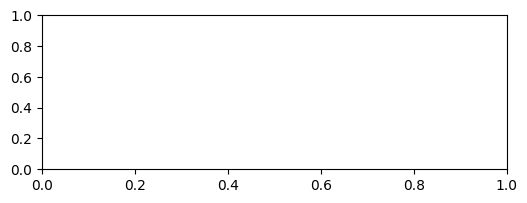

In [23]:
# Critical Difference diagrams per metric
higher_is_better_metrics = {"valid", "ImprovementOverNUN"}

paper_method_name_map = {
    "Multi-SpaCE ($p^p=0.75$)": "Multi-SpaCE",
}
paper_metric_name_map = {
    "sparsity": "Sparsity",
    "L2": "Proximity",
    "valid": "Validity",
    "subsequences": "Contiguity",
    "times": "Execution Time",
    "AE_IOS": "IOS(AE)", "IF_IOS": "IOS(IF)", "LOF_IOS": "IOS(LOF)",
    "AE_OS": "OS(AE)", "IF_OS": "OS(IF)", "LOF_OS": "OS(LOF)",
    "ImprovementOverNUN": "IoN",
}

cd_summary_df = generate_critical_difference_diagrams(
    results_df=complete_results_df,
    metrics=metrics,
    higher_is_better_metrics=higher_is_better_metrics,
    alpha=0.05,
    posthoc="wilcoxon_holm",
    rank_tie_method="min",
    use_precomputed_ranks=True,
    ranked_results_df=ranked_data,
    method_name_map=paper_method_name_map,
    metric_name_map=paper_metric_name_map,
    highlight_method="FastPACE",
    highlight_method_color=None,
    highlight_method_fontsize=10,
    highlight_method_fontweight=None,
    highlight_connector=True,
    highlight_connector_color=None,
    highlight_connector_linewidth=1.6,

    figsize=(6,2),
    fig_height=3.5,
    method_label_fontsize=10,
    rank_number_fontsize=10,
    method_spacing=1.0,
    text_h_margin=0.05,
    save_plots=False,
    save_dir="./experiments/evaluation/cd_plots_multi",
    save_ext="png",
    save_suffix="multi",
    save_dpi=300,
)

# display(cd_summary_df)


In [42]:
rename_method_dict = {"Multi-SpaCE ($p^p=0.75$)": 'Multi-SpaCE'}
rename_metric_dict = {
    "AE_IOS": "IOS(AE)", "IF_IOS": "IOS(IF)", "LOF_IOS": "IOS(LOF)",
    "AE_OS": "OS(AE)", "IF_OS": "OS(IF)", "LOF_OS": "OS(LOF)",
}
rename_dataset_dict = {
    "ProximalPhalanxOutlineCorrect": "PPOC", "NonInvasiveFatalECGThorax2": "NI-ECG2",
    'ArticularyWordRecognition': "AWR", "SelfRegulationSCP1": "SR-SCP1", "UWaveGestureLibrary": "UWave"
}
dataset_order = [
    'AWR', "BasicMotions", 'Cricket', 'Epilepsy', 
    "NATOPS", 'PEMS-SF', 'PenDigits', 'RacketSports', 'SR-SCP1',
    "UWave",
]

method_order = [
    'NG', 'Glacier', 'Glacier(AE)', 'COMTE', 'AB-CF', 'DiscoX', 'Multi-SpaCE'
]

In [43]:
def _extract_mean(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "-" or s == "":
        return np.nan
    # expected formats: "m ± s" or "m+/-s" etc.
    if "±" in s:
        s = s.split("±", 1)[0]
    elif "+/-" in s:
        s = s.split("+/-", 1)[0]
    return float(s.strip())

In [44]:
# Create simple result tables
simple_metrics = ["sparsity", "L2", "valid", "subsequences", "subsequences %", "AE_OS", "IF_OS", "LOF_OS", "times"]
higher_is_better_metrics = ["valid"]

for metric, metric_pivot_df_orig in metric_pivots_df.items():
    if metric in simple_metrics:
        print(metric)
        metric_pivot_df = metric_pivot_df_orig.copy()
        # Order methods and datasets
        metric_pivot_df = metric_pivot_df.rename(columns=rename_method_dict, index=rename_dataset_dict)
        ordered_methods = [col for col in method_order if col in metric_pivot_df.columns]
        metric_pivot_df = metric_pivot_df[ordered_methods]
        ordered_datasets = [dataset for dataset in dataset_order if dataset in metric_pivot_df.index]
        metric_pivot_df = metric_pivot_df.loc[dataset_order + ["Average Rank"]]
        method_names = metric_pivot_df.columns

        # Create table header
        table_header_fixed = """
\\begin{table}[ht]
\\centering
\\begin{tabular}{l|""" + "".join(["c"] * len(method_names)) + "}\n\\hline\n"

        table_columns = "Dataset & " + " & ".join(method_names) + " \\\\\n\hline\n"

        table_rows = []
        for dataset, row in metric_pivot_df.iterrows():
            if dataset == "Average Rank":
                table_rows.append("\hline")
            row_data = [dataset]
            # NEW: compute best/second-best using MEAN only
            numeric_values = row[method_names].apply(_extract_mean).dropna()
            best_value = np.nan
            second_best_value = np.nan
            
            if len(numeric_values) > 0:
                if (metric in higher_is_better_metrics) and (dataset != "Average Rank"):
                    best_value = numeric_values.max()
                    # second-best = next distinct max after best
                    remaining = numeric_values[~np.isclose(numeric_values.values, best_value, atol=1e-12, rtol=0.0)]
                    if len(remaining) > 0:
                        second_best_value = remaining.max()
                else:
                    best_value = numeric_values.min()
                    # second-best = next distinct min after best
                    remaining = numeric_values[~np.isclose(numeric_values.values, best_value, atol=1e-12, rtol=0.0)]
                    if len(remaining) > 0:
                        second_best_value = remaining.min()


            for method in method_names:
                value = row[method]
                if pd.isna(value):
                    formatted_value = "-"
                else:
                    # CHANGED: keep the original "mean ± std" string (don’t round as float)
                    formatted_value = str(value)
                    # compare using the mean extracted from the cell
                    mean_val = _extract_mean(value)

                    # CHANGED: compare by method identity (based on mean ranking)
                    if not np.isnan(best_value) and np.isclose(mean_val, best_value, atol=1e-12, rtol=0.0):
                        formatted_value = f"\\textbf{{{formatted_value}}}"
                    elif not np.isnan(second_best_value) and np.isclose(mean_val, second_best_value, atol=1e-12, rtol=0.0):
                        formatted_value = f"\\underline{{{formatted_value}}}"

                row_data.append(formatted_value)
            table_rows.append(" & ".join(row_data) + " \\\\")

        table_footer = """
\\hline
\\end{tabular}
\\end{table}
"""
        latex_table = table_header_fixed + table_columns + "\n".join(table_rows) + table_footer
        print(latex_table)

sparsity

\begin{table}[ht]
\centering
\begin{tabular}{l|ccc}
\hline
Dataset & COMTE & AB-CF & DiscoX \\
\hline
AWR & \textbf{0.2 ± 0.1} & 0.5 ± 0.18 & \underline{0.36 ± 0.08} \\
BasicMotions & \textbf{0.15 ± 0.1} & 0.56 ± 0.2 & \underline{0.22 ± 0.09} \\
Cricket & nan ± nan & \textbf{0.6 ± 0.16} & nan ± nan \\
Epilepsy & \textbf{0.23 ± 0.1} & 0.56 ± 0.13 & \underline{0.37 ± 0.12} \\
NATOPS & \textbf{0.16 ± 0.07} & 0.6 ± 0.27 & \underline{0.21 ± 0.09} \\
PEMS-SF & nan ± nan & \textbf{0.5 ± 0.2} & nan ± nan \\
PenDigits & \textbf{0.34 ± 0.1} & 0.63 ± 0.22 & \underline{0.39 ± 0.12} \\
RacketSports & \textbf{0.14 ± 0.07} & 0.71 ± 0.29 & \underline{0.2 ± 0.05} \\
SR-SCP1 & \textbf{0.07 ± 0.08} & 0.57 ± 0.27 & \underline{0.16 ± 0.09} \\
UWave & \textbf{0.11 ± 0.07} & 0.46 ± 0.21 & \underline{0.28 ± 0.07} \\
\hline
Average Rank & \textbf{2.125} & 5.5 & \underline{4.375} \\
\hline
\end{tabular}
\end{table}

L2

\begin{table}[ht]
\centering
\begin{tabular}{l|ccc}
\hline
Dataset & COMTE & AB-CF

In [45]:
metrics_trad_dict = {'nchanges': '# changes', 'sparsity': 'Sparsity', 'L1': 'Proximity ($L_1$)', 'L2': 'Proximity ($L_2$)', 'valid': 'Validity',
                     'increase_outlier_score': 'IOS', 'subsequences': 'NoS', 'subsequences %': 'NoS [%]'}
groupby_trad_dict = {'method': 'Method' , 'dataset': 'Dataset'}

metrics = list(metrics_trad_dict.values())
groupby_cols = list(groupby_trad_dict.values())

final_df = results_all_datasets_df.rename(columns={**metrics_trad_dict, **groupby_trad_dict})
final_df = final_df.replace({**rename_method_dict, **rename_dataset_dict})
final_df['Validity'] = final_df['Validity'].astype(int)

methods = ['Glacier', 'Glacier(AE)', 'NG', 'COMTE', 'AB-CF', 'DiscoX', 'M-CELS Sec.', "MASCOTS", 'Multi-SpaCE Global']

aux_df = final_df.copy()
aux_df = aux_df[aux_df["Method"].isin(methods)]
aux_df['(Sparsity + NoS[%]) / 2'] = (aux_df['Sparsity'] + aux_df['NoS [%]']**0.25) / 2
# aux_df['(sparsity + contiguity) / 2'] = (aux_df['NoS'] / aux_df['# changes'] ) 
aux_df['Method_ord'] = aux_df['Method'].map( dict(zip(methods, list(range(len(methods))))) )
aux_df['Dataset_ord'] = aux_df['Dataset'].map( dict(zip(dataset_order, list(range(len(dataset_order))))) )
aux_df = aux_df.reset_index()
aux_df = aux_df.sort_values(['Dataset_ord', 'Method_ord'], ascending=True)

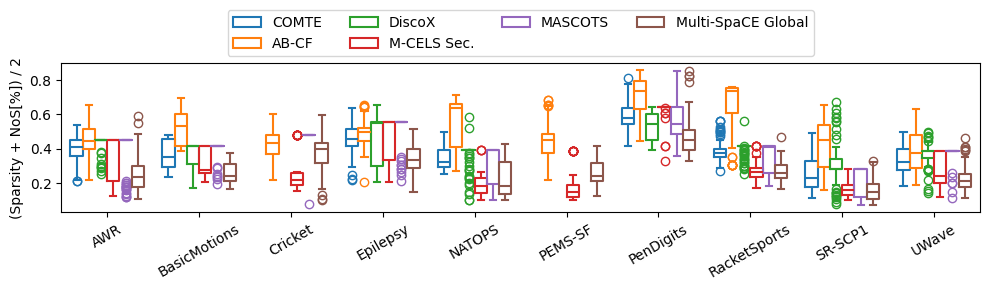

In [46]:
plt.figure(figsize=(10, 3))
ax = sns.boxplot(data=aux_df, x="Dataset", y="(Sparsity + NoS[%]) / 2", hue="Method", fill=False)
# ax.legend(loc='upper right')
sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=4, title=None)
ax.set(xlabel=None)
plt.xticks(rotation=30)
plt.tight_layout()
# plt.savefig('./experiments/results/multivariate-sparsity-contiguity.PNG', dpi=300)

In [75]:
datasets_trad_dict = {"CBF": "CBF", "chinatown": "Chinatown", "coffee": "Coffee", "gunpoint": "Gunpoint"}
datasets_order = dict(zip(list(datasets_trad_dict.values()), list(range(len(datasets_trad_dict)))))

metrics_trad_dict = {'nchanges': '# changes', 'sparsity': 'Sparsity', 'L1': 'Proximity ($L_1$)', 'L2': 'Proximity ($L_2$)', 'valid': 'Validity',
                     'increase_outlier_score': 'IOS', 'subsequences': 'NoS', 'subsequences %': 'NoS [%]'}

groupby_trad_dict = {'method': 'Method' , 'dataset': 'Dataset'}

metrics = list(metrics_trad_dict.values())
groupby_cols = list(groupby_trad_dict.values())

In [34]:
final_df = results_all_datasets_df.rename(columns={**metrics_trad_dict, **groupby_trad_dict})
final_df = final_df.replace(datasets_trad_dict)
final_df['Validity'] = final_df['Validity'].astype(int)

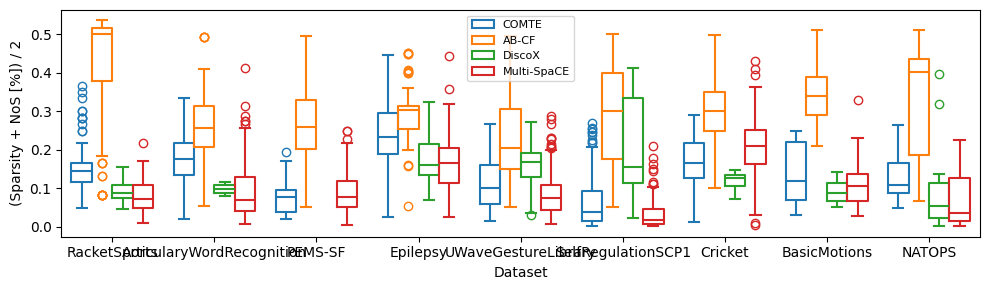

In [35]:
methods = [
    # "multisubspace_gknn_75_0_25_mut01",
    # "multisubspace_gknn_75_0_25_mut02",
    # "multisubspace_gknn_75_0_25_mut03",
    # "multisubspace_gknn_75_0_25_mut04",
    # "multisubspace_gknn_75_0_25_mut05",
    # "multisubspace_gknn_75_0_25_mut06",
    # "multisubspace_gknn_75_0_25_mut07",
    # "multisubspace_gknn_75_0_25_mut08",
    # "multisubspace_gknn_75_0_25_mut09",

    "COMTE",
    "AB-CF",
    "DiscoX",
    "Multi-SpaCE"
]
methods_order = dict(zip(methods, list(range(len(methods)))))

aux_df = final_df.copy()
aux_df = aux_df[aux_df['Method'].isin(methods)]
aux_df['(Sparsity + NoS [%]) / 2'] = (aux_df['Sparsity'] + aux_df['NoS [%]']) / 2
aux_df['Sparsity / NoS [%]'] = aux_df['Sparsity'] / aux_df['NoS [%]'] 
aux_df['Method_ord'] = aux_df['Method'].map( dict(zip(methods, list(range(len(methods))))) )
aux_df = aux_df.reset_index()
aux_df = aux_df.sort_values('Method_ord', ascending=True)


plt.figure(figsize=(10, 3))
ax = sns.boxplot(data=aux_df[aux_df["Dataset"]!="PenDigits"], x="Dataset", y='(Sparsity + NoS [%]) / 2', hue="Method", fill=False)
ax.legend(loc='upper right')
plt.legend(fontsize=8)
plt.tight_layout()

In [36]:
times_df = pd.DataFrame()
for dataset in DATASETS:
    X_train, y_train, X_test, y_test = data_dict[dataset]
    dataset_ts_len, dataset_nchannels = X_train.shape[1], X_train.shape[2]
    dataset_times = results_all_datasets_df[results_all_datasets_df["dataset"] == dataset][['times', 'method', 'dataset']]
    dataset_times["dataset_ts_len"] = dataset_ts_len
    dataset_times["dataset_nchannels"] = dataset_nchannels
    times_df = pd.concat([times_df, dataset_times])
times_df = times_df.rename(columns={"times": "Seconds", "dataset_ts_len": "Time series length", 
                                    "method": "Method", "dataset_nchannels": "Channels"})

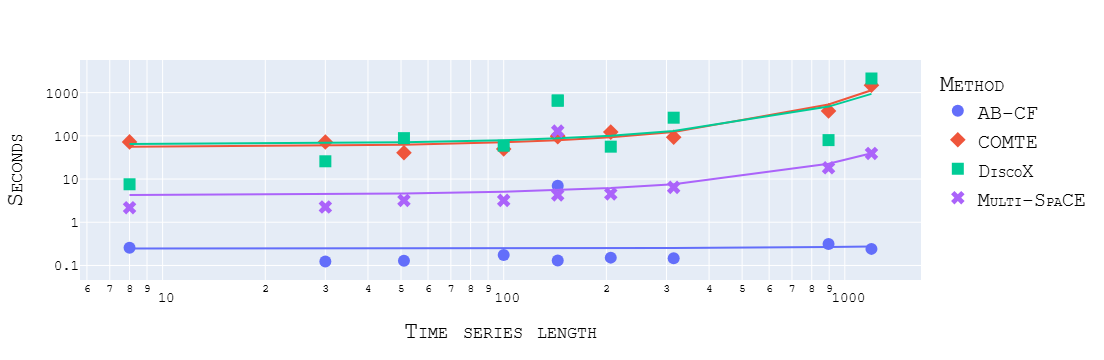

In [41]:
config = {
  'toImageButtonOptions': {
    'format': 'png', # one of png, svg, jpeg, webp
    'filename': 'multivariate_times_length',
    'height': 400,
    'width': 1200,
    'scale':9 # Multiply title/legend/axis/canvas sizes by this factor
  }
}

fig = px.scatter(
    times_df.groupby(["dataset", "Method"]).mean().reset_index(), 
    x="Time series length", y="Seconds", color="Method", 
    symbol="Method", trendline="ols", 
    trendline_options=dict(log_y=True), log_x=True, log_y=True
)
fig.update_traces(marker={'size': 12})
fig.update_layout(
    yaxis = dict(tickfont = dict(size=14)),
    xaxis = dict(tickfont = dict(size=14)),
    font=dict(
            family="Courier New, monospace",
            size=20,
            color="black",
            variant="small-caps",
        )
)
fig.show(config=config)
fig.write_html("img_multivariate_times_length.html")



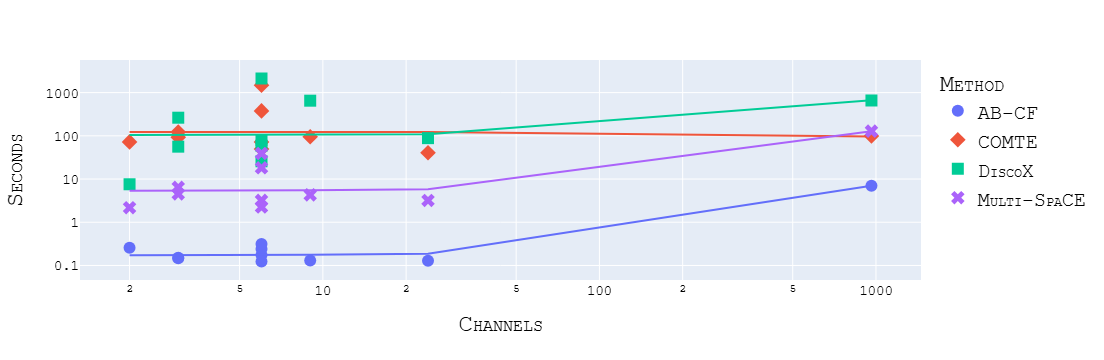

In [42]:
config = {
  'toImageButtonOptions': {
    'format': 'png', # one of png, svg, jpeg, webp
    'filename': 'multivariate_times_channels',
    'height': 400,
    'width': 1200,
    'scale':9 # Multiply title/legend/axis/canvas sizes by this factor
  }
}

fig = px.scatter(
    times_df.groupby(["dataset", "Method"]).mean().reset_index(), 
    x="Channels", y="Seconds", color="Method", 
    symbol="Method", trendline="ols", 
    trendline_options=dict(log_y=True), log_x=True, log_y=True
)
fig.update_traces(marker={'size': 12})
fig.update_layout(
    yaxis = dict(tickfont = dict(size=14)),
    xaxis = dict(tickfont = dict(size=14)),
    font=dict(
            family="Courier New, monospace",
            size=20,
            color="black",
            variant="small-caps",
        )
)
fig.show(config=config)
fig.write_html("img_multivariate_times_channels.html")

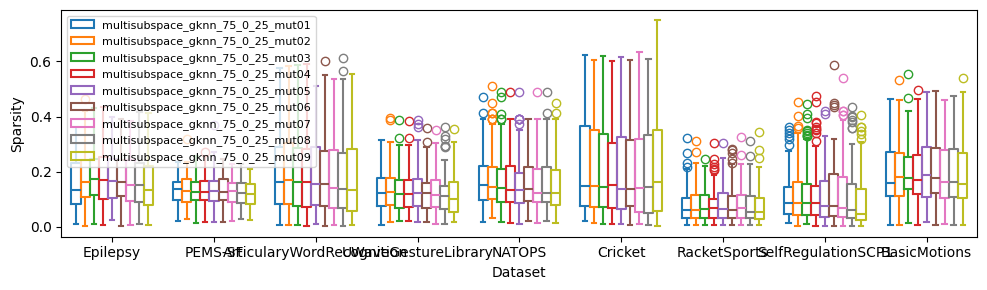

In [47]:
plt.figure(figsize=(10, 3))
ax = sns.boxplot(data=aux_df[aux_df["Dataset"]!="PenDigits"], x="Dataset", y='Sparsity', hue="Method", fill=False)
ax.legend(loc='upper right')
plt.legend(fontsize=8)
plt.tight_layout()

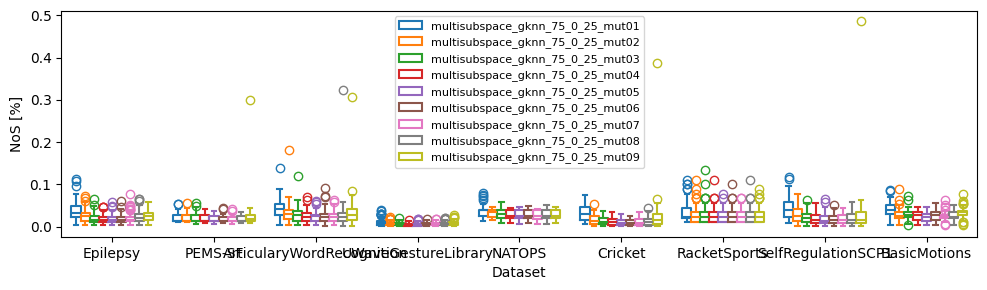

In [48]:
plt.figure(figsize=(10, 3))
ax = sns.boxplot(data=aux_df[aux_df["Dataset"]!="PenDigits"], x="Dataset", y='NoS [%]', hue="Method", fill=False)
ax.legend(loc='upper right')
plt.legend(fontsize=8)
plt.tight_layout()

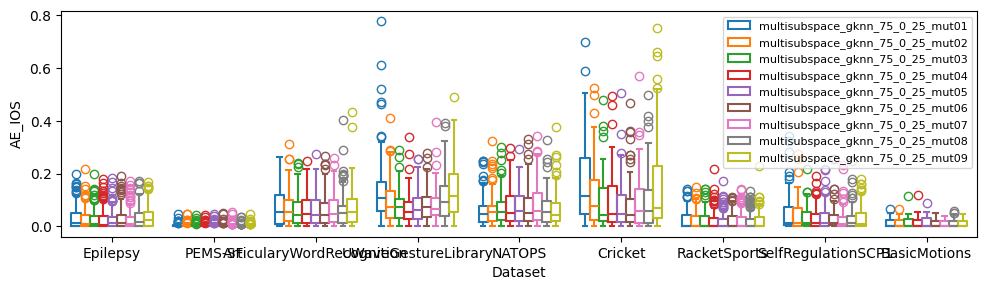

In [49]:
plt.figure(figsize=(10, 3))
ax = sns.boxplot(data=aux_df[aux_df["Dataset"]!="PenDigits"], x="Dataset", y='AE_IOS', hue="Method", fill=False)
ax.legend(loc='upper right')
plt.legend(fontsize=8)
plt.tight_layout()

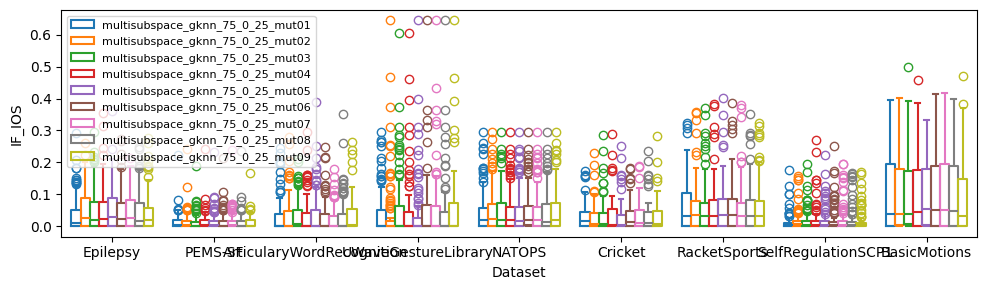

In [50]:
plt.figure(figsize=(10, 3))
ax = sns.boxplot(data=aux_df[aux_df["Dataset"]!="PenDigits"], x="Dataset", y='IF_IOS', hue="Method", fill=False)
ax.legend(loc='upper right')
plt.legend(fontsize=8)
plt.tight_layout()

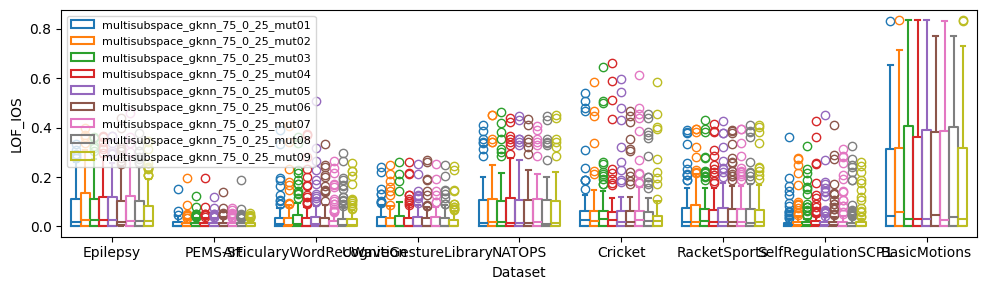

In [51]:
plt.figure(figsize=(10, 3))
ax = sns.boxplot(data=aux_df[aux_df["Dataset"]!="PenDigits"], x="Dataset", y='LOF_IOS', hue="Method", fill=False)
ax.legend(loc='upper right')
plt.legend(fontsize=8)
plt.tight_layout()

# Counterfactual visualization

In [168]:
import math
def plot_comp_cfs(x_orig, possible_nuns, x_cfs_dict, store=False):
    
    # Calculate auxiliary variables
    method_names = list(x_cfs_dict.keys())
    x_cfs = list(x_cfs_dict.values())
    length = x_orig.shape[0]
    n_channels = x_orig.shape[1]

    # Define outer grid
    grid_columns = 4
    grid_rows = math.ceil(len(x_cfs) / grid_columns)
    fig = plt.figure(figsize=(18, grid_rows*4), dpi=600)
    outer_grid = gridspec.GridSpec(grid_rows, grid_columns, wspace=0.2, hspace=0.3)

    # Iterate through outer grid plots
    for m, outer in enumerate(outer_grid):
        try:
            # Get change mask 
            x_cf = x_cfs[m]
            method_name = method_names[m]
            """# Get nuns used by the method depending on the name
            if "gknn" in method_name:
                nun_example = possible_nuns["gknn"]
            elif "iknn" in method_name:
                nun_example = possible_nuns["iknn"]
            else:
                raise ValueError('Not detected NUN finding procedure in name. Method name must contain "gknn" or "iknn"')"""
            # found_counterfactual_mask = (x_orig != x_cf.reshape(1, length, n_channels)).astype(int)
            proximity_values = np.abs(x_orig - x_cf.reshape(1, length, n_channels))
            found_counterfactual_mask = (proximity_values > np.abs(x_orig)/proximity_values*0.0001).astype(int)
            diff_mask = np.diff(found_counterfactual_mask, prepend=0, append=0, axis=1)
        except IndexError:
            break
    
        # Create inner grid
        inner_grid = gridspec.GridSpecFromSubplotSpec(n_channels, 1, wspace=0.2, hspace=0.2, subplot_spec=outer)
        sub_channel_axs = []
        for i in range(n_channels):
            ax = plt.Subplot(fig, inner_grid[i])
            # ax.plot(nun_example.reshape(1, length, n_channels)[:, :, i].flatten(), color='grey')
            ax.plot(x_cf.reshape(1, length, n_channels)[:, :, i].flatten(), color='red')
            ax.plot(x_orig.reshape(1, length, n_channels)[:, :, i].flatten(), color="#332288")
            ax.set_yticklabels([])
            ax.set_xticklabels([])
            ax.axis('off')
            # Set title if first channel
            if i == 0:
                ax.set_title(method_name)
            
            # Add fill to changes
            starts = np.clip( np.where(diff_mask[0, :, i].flatten() == 1)[0] - 1 , 0, length)
            ends = np.where(diff_mask[0, :, i].flatten() == -1)[0]
            # Iterate over the mask segments and fill them with red color
            for i in range(0, len(starts)):
                start_idx = starts[i]
                end_idx = ends[i]
                # plt.fill_between(comp_df.iloc[start_idx:end_idx].index, comp_df.min(), comp_df.max(), color='red', alpha=0.7)
                ax.axvspan(start_idx, end_idx, alpha=0.2, color='red')
            
            # Add ax to list of subplots
            fig.add_subplot(ax)
            sub_channel_axs.append(ax)

    # Plot figure
    """fig.legend(
        sub_channel_axs,     # The line objects
        labels=['x_cf', 'x_orig'],   # The labels for each line
        loc='center',
        prop={'size': 12}
    )"""
    plt.tight_layout()
    # plt.show()
    if store:
        plt.savefig(f'./experiments/results/examples_cfs_{dataset}_instance_{instance_index}.png', dpi=600)



In [169]:
dataset = 'ArticularyWordRecognition'
rename_method_dict = {"Multi-SpaCE ($p^p=0.5$)": 'Multi-SpaCE'}

aux_results_dataset = results_all_datasets_df[results_all_datasets_df["dataset"]==dataset].sort_values(by="ii")

with pd.option_context("display.max_rows", None,): 
    display(aux_results_dataset[aux_results_dataset["method"]=="M-CELS"])

,ii,nchanges,sparsity,L1,L2,proba,valid,nuns_valid,AE_OS,IF_OS,...,IF_IOS,LOF_IOS,subsequences,subsequences %,(sparsity + subsequences %) / 2,times,method,best cf index,order,dataset
520,0,58.0,0.044753,65.030841,9.386706,0.541661,True,NaN,0.539015,0.578243,...,0.053856,0.022927,12.0,0.018519,0.031636,17.265998,M-CELS,0,1,ArticularyWordRecognition
521,3,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,14.445886,M-CELS,0,1,ArticularyWordRecognition
522,13,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,14.153052,M-CELS,0,1,ArticularyWordRecognition
523,14,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,13.502747,M-CELS,0,1,ArticularyWordRecognition
524,15,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,12.944224,M-CELS,0,1,ArticularyWordRecognition
525,19,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,13.600943,M-CELS,0,1,ArticularyWordRecognition
526,22,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,13.353345,M-CELS,0,1,ArticularyWordRecognition
527,23,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,30.896240,M-CELS,0,1,ArticularyWordRecognition
528,25,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,29.598483,M-CELS,0,1,ArticularyWordRecognition
529,29,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,29.857881,M-CELS,0,1,ArticularyWordRecognition


In [170]:
desired_methods = ["COMTE", "AB-CF", "DiscoX", "M-CELS", "Multi-SpaCE ($p^p=0.5$)", "Multi-SpaCE"]
common_index_instance = 0

Sample 0: true class 0, x_orig predicted 0, desired_class  9


/tmp/ipykernel_2073455/2961566328.py:31: RuntimeWarning: divide by zero encountered in divide
  found_counterfactual_mask = (proximity_values > np.abs(x_orig)/proximity_values*0.0000001).astype(int)
/tmp/ipykernel_2073455/2961566328.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


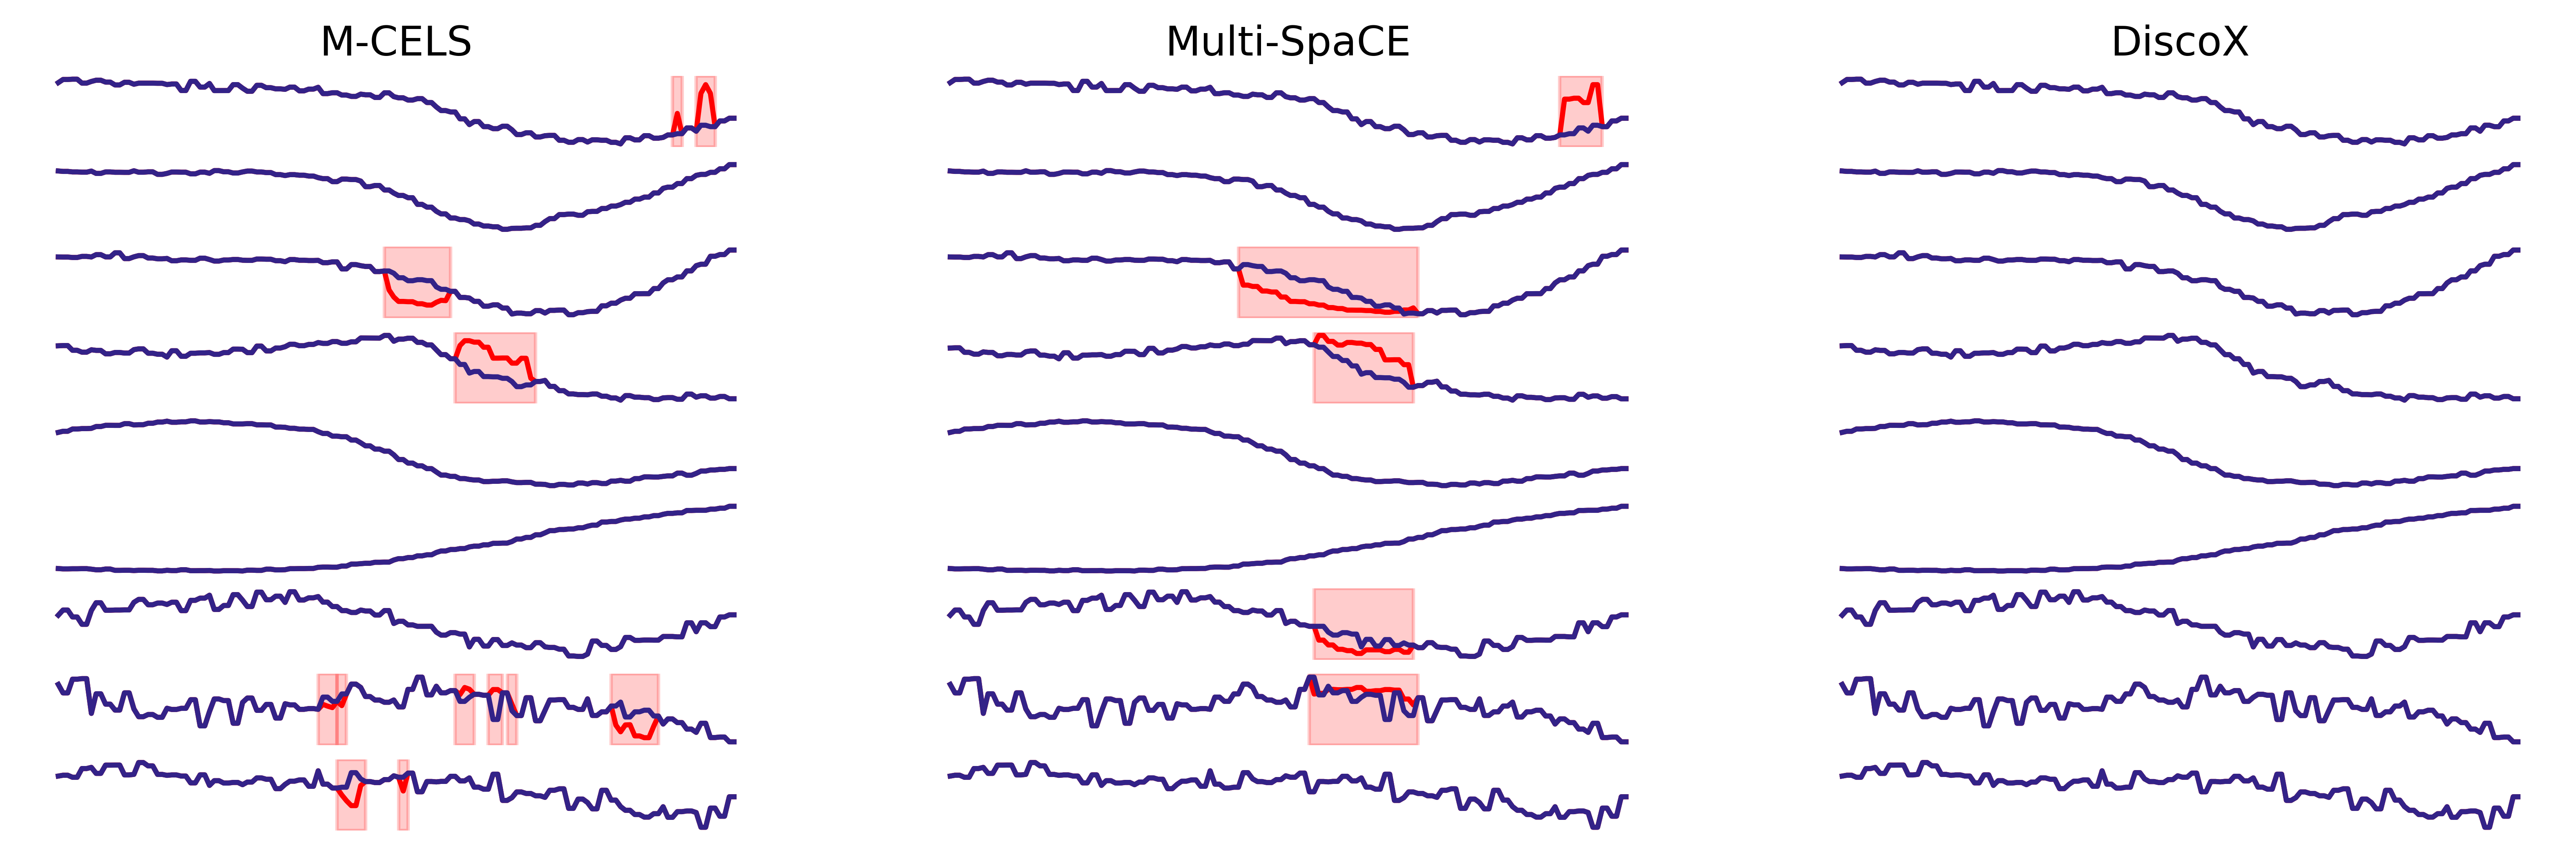

In [171]:
# Get data
X_train, y_train, X_test, y_test = data_dict[dataset]
common_indexes = common_test_indexes_dict[dataset]
instance_index = common_indexes[common_index_instance]

# Get common cfs calculated for all method
x_orig = X_test[instance_index]

# Get possible NUNs
possible_nuns = possible_nuns_dict[dataset]
possible_nuns_instance = {type: possible_nuns[type][instance_index] for type in ["gknn"]}

# Get original class and desired class
original_class = original_classes_dict[dataset][instance_index]
desired_class = desired_classes_dict[dataset][instance_index]

# Get the cf calculated for all methods
sol_cfs_methods = {}
sol_methods = methods_cfs_dict[dataset]
if desired_methods is not None:
    sol_methods = {method: solutions for method, solutions in sol_methods.items() if method in desired_methods}

# Add manually DiscoX
if "DiscoX" not in sol_methods:
    DiscoX_sols = []
    for common_index in common_indexes:
        sol_dict = {}
        sol_dict["time"] = -1
        sol_dict["cf"] = np.expand_dims(X_test[common_index], axis=0)
        DiscoX_sols.append(sol_dict)
    sol_methods["DiscoX"] = DiscoX_sols


    
for method, solutions in sol_methods.items():
    if 'cfs' in solutions[0]:
        counterfactuals = [solution['cfs'] for solution in solutions]
    else:
        counterfactuals = [solution['cf'] for solution in solutions] 
    # Extract best counterfactual in case of multi objective
    counterfactual = counterfactuals[common_index_instance]
    # Extract best index solution
    aux_results_dataset_method = aux_results_dataset[aux_results_dataset["method"] == method]

    if len(aux_results_dataset_method) > 0:
        best_cf_index = aux_results_dataset_method.iloc[common_index_instance]["best cf index"]
        best_cf = counterfactual[best_cf_index]
        best_cf = np.expand_dims(best_cf, axis=0)
    else:
        best_cf_index = 0
        best_cf = counterfactual[best_cf_index]
        best_cf = np.expand_dims(best_cf, axis=0)
        
    # Append to dictionary
    new_method_name = method
    if method in rename_method_dict:
        new_method_name = rename_method_dict[method]
    sol_cfs_methods[new_method_name] = best_cf
    
# Show result
print(f'Sample {instance_index}: true class {y_test[instance_index]}, x_orig predicted {original_class}, desired_class  {desired_class}')
plot_comp_cfs(x_orig, possible_nuns_instance, sol_cfs_methods, store=False)

In [137]:
# Create plot with examples of each method in each dataset

In [ ]:
# CBF: 1, 2, 10, 18, 19
# chinatown: 3, 7, 19
# coffee: 1, 3, 9, 16
# ECG200: 0, 13
# gunpoint: 9, 10, 15 (pesimos en general)
dataset_samples = [('CBF', 2), ('chinatown', 19), ('coffee', 3), ('ECG200', 13), ('gunpoint', 15)]
methods_trad_dict = {"wcf_ng": "W-CF", "ng": "NG", "ab_cf": "AB-CF", "subspace": "Sub-SpaCE"}
methods = list(methods_trad_dict.keys())
include_nun_list = [False, False, False, False]

In [ ]:
from collections import OrderedDict

# Define outer grid
fig = plt.figure(figsize=(16, 6))
grid_rows = len(methods)
grid_columns = len(dataset_samples)
outer_grid = gridspec.GridSpec(grid_rows, grid_columns, wspace=0, hspace=0)

# Iterate through outer grid plots
for i_outer, outer in enumerate(outer_grid):
    i_dataset = i_outer % grid_columns
    dataset, instance = dataset_samples[i_dataset]
    column_title = f'{dataset} instance {instance}'
    
    X_train, y_train, X_test, y_test = data_dict[dataset]
    nuns_idx = nuns_idx_dict[dataset]
    sol_cfs_methods = sol_cfs_dict[dataset]
    sol_cfs_methods = {method: sol_cfs_methods[method][instance]['cf'] for method in methods}

    # Calculate auxiliary variables
    method_names = list(sol_cfs_methods.keys())
    x_cfs = list(sol_cfs_methods.values())
    x_orig = X_test[instance]
    nun_example = X_train[nuns_idx[instance]]
    length = x_orig.shape[0]
    n_channels = x_orig.shape[1]

    # get method m
    m = i_outer // grid_columns
    try:
        # Get change mask 
        x_cf = x_cfs[m]
        method_name = method_names[m]
        found_counterfactual_mask = (x_orig != x_cf.reshape(1, length, n_channels)).astype(int)
        diff_mask = np.diff(found_counterfactual_mask, prepend=0, append=0, axis=1)
    except IndexError:
        break

    # Create inner grid
    inner_grid = gridspec.GridSpecFromSubplotSpec(n_channels, 1, wspace=0, hspace=0, subplot_spec=outer)
    sub_channel_axs = []
    for i in range(n_channels):
        ax = plt.Subplot(fig, inner_grid[i])
        if include_nun_list[m]:
            ax.plot(nun_example.reshape(1, length, n_channels)[:, :, i].flatten(), color='grey')
        ax.plot(x_cf.reshape(1, length, n_channels)[:, :, i].flatten(), color='red')
        ax.plot(x_orig.reshape(1, length, n_channels)[:, :, i].flatten(), color="#332288")
        # ax.axis("off")
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add fill to changes
        starts = np.clip( np.where(diff_mask[0, :, i].flatten() == 1)[0] - 1 , 0, length)
        ends = np.where(diff_mask[0, :, i].flatten() == -1)[0]
        # Iterate over the mask segments and fill them with red color
        for i in range(0, len(starts)):
            start_idx = starts[i]
            end_idx = ends[i]
            # plt.fill_between(comp_df.iloc[start_idx:end_idx].index, comp_df.min(), comp_df.max(), color='red', alpha=0.7)
            ax.axvspan(start_idx, end_idx, alpha=0.2, color='red')
        
        # Set column titles
        if m == 0:
            ax.set_title(column_title)
        if i_dataset == 0:
            ax.set_ylabel(methods_trad_dict[method_name], size='large')
        # Add ax to list of subplots
        fig.add_subplot(ax)
        sub_channel_axs.append(ax)

# Plot figure
plt.tight_layout()
"""fig.legend(
    sub_channel_axs,     # The line objects
    labels=['$x^n$', 'x', "x'"],   # The labels for each line
    loc='lower center',
    # loc='center right',
    prop={'size': 14},
    ncol=3
)"""
# plt.show()
# plt.savefig('./experiments/results/examples_cfs.png', dpi=300)


In [ ]:
from collections import OrderedDict

# Define outer grid
fig = plt.figure(figsize=(12, 12))
grid_rows = len(dataset_samples)
grid_columns = len(methods)
outer_grid = gridspec.GridSpec(grid_rows, grid_columns, wspace=0, hspace=0)

# Iterate through outer grid plots
for i_outer, outer in enumerate(outer_grid):
    i_dataset = i_outer // grid_columns
    dataset, instance = dataset_samples[i_dataset]
    
    X_train, y_train, X_test, y_test = data_dict[dataset]
    nuns_idx = nuns_idx_dict[dataset]
    sol_cfs_methods = sol_cfs_dict[dataset]
    sol_cfs_methods = {method: sol_cfs_methods[method][instance]['cf'] for method in methods}

    # Calculate auxiliary variables
    method_names = list(sol_cfs_methods.keys())
    x_cfs = list(sol_cfs_methods.values())
    x_orig = X_test[instance]
    nun_example = X_train[nuns_idx[instance]]
    length = x_orig.shape[0]
    n_channels = x_orig.shape[1]

    # get method m
    m = i_outer % grid_columns
    try:
        # Get change mask 
        x_cf = x_cfs[m]
        method_name = method_names[m]
        found_counterfactual_mask = (x_orig != x_cf.reshape(1, length, n_channels)).astype(int)
        diff_mask = np.diff(found_counterfactual_mask, prepend=0, append=0, axis=1)
    except IndexError:
        break
    
    # Create inner grid
    inner_grid = gridspec.GridSpecFromSubplotSpec(n_channels, 1, wspace=0, hspace=0, subplot_spec=outer)
    sub_channel_axs = []
    for i in range(n_channels):
        ax = plt.Subplot(fig, inner_grid[i])
        if include_nun_list[m]:
            ax.plot(nun_example.reshape(1, length, n_channels)[:, :, i].flatten(), color='grey')
        ax.plot(x_cf.reshape(1, length, n_channels)[:, :, i].flatten(), color='red')
        ax.plot(x_orig.reshape(1, length, n_channels)[:, :, i].flatten(), color="#332288")
        # ax.axis("off")
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add fill to changes
        starts = np.clip( np.where(diff_mask[0, :, i].flatten() == 1)[0] - 1 , 0, length)
        ends = np.where(diff_mask[0, :, i].flatten() == -1)[0]
        # Iterate over the mask segments and fill them with red color
        for i in range(0, len(starts)):
            start_idx = starts[i]
            end_idx = ends[i]
            # plt.fill_between(comp_df.iloc[start_idx:end_idx].index, comp_df.min(), comp_df.max(), color='red', alpha=0.7)
            ax.axvspan(start_idx, end_idx, alpha=0.2, color='red')
        
        # Set column titles
        column_title = methods_trad_dict[method_name]
        # row_title = f'{dataset} \n instance {instance}'
        row_title = f'{dataset} [{instance}]'
        if m == 0:
            ax.set_ylabel(row_title, fontsize=16, rotation=90)
        if i_dataset == 0:
            ax.set_title(column_title, fontsize=18)
            
        # Add ax to list of subplots
        fig.add_subplot(ax)
        sub_channel_axs.append(ax)

# Plot figure
plt.tight_layout()
"""fig.legend(
    sub_channel_axs,     # The line objects
    labels=['$x^n$', 'x', "x'"],   # The labels for each line
    # loc='lower center',
    loc='center right',
    prop={'size': 18},
    ncol=1
)"""
# plt.show()
plt.savefig('./experiments/results/examples_cfs.png', dpi=300)


# Explore Pareto-Front

In [610]:
import json
from methods.MultiSubSpaCE.FitnessFunctions import fitness_function_mo

In [1067]:
dataset = "ArticularyWordRecognition"
method_dir_name = "d98ff072a62c4346b035510c421f3498e40f8bbc"

In [1068]:
# Load all info needed to get the counterfactual
data_tuple, original_classes, model, outlier_calculators, possible_nuns, desired_classes = load_dataset_for_eval(dataset, model_to_explain, osc_names)
X_train, y_train, X_test, y_test = data_tuple

# Load solution cfs
with open(f'./experiments/results/{dataset}/{model_to_explain}/{method_dir_name}/counterfactuals.pickle', 'rb') as f:
    solutions = pickle.load(f)
    counterfactuals = [solution['cfs'] for solution in solutions]

# Load params
with open(f'./experiments/results/{dataset}/{model_to_explain}/{method_dir_name}/params.json', 'r') as json_file:
    params = json.load(json_file)
    test_indexes = params["X_test_indexes"]

# Get nuns used by the method depending on the name
if "independent_channels_nun" in params:
    if params["independent_channels_nun"]:
        nuns = possible_nuns["iknn"]
    else:
        nuns = possible_nuns["gknn"]
else:
    nuns = np.array([None]*len(X_test))

# Adapt for subsample
X_test = X_test[test_indexes]
nuns = nuns[test_indexes]
desired_classes = desired_classes[test_indexes]


In [1116]:
instance = 35
# instance = 1

In [1129]:
# Get x, x' and y'
counterfactuals_i = counterfactuals[instance]
x_orig_i = X_test[instance]
nun_i = nuns[instance]
desired_class = desired_classes[instance]

# Calculate objective values
predicted_probs = model.predict(counterfactuals_i, verbose=0)
# Get outlier scores from AE to get the best CF
if outlier_calculators is not None:
    aux_outlier_scores = outlier_calculators["AE"].get_outlier_scores(counterfactuals_i)
else:
    aux_outlier_scores = np.zeros((predicted_probs.shape[0], 1))
# Get fitness scores
change_masks = (counterfactuals_i != x_orig_i).astype(int)
objective_fitness = fitness_function_mo(
    change_masks, predicted_probs, desired_class, aux_outlier_scores,
    outlier_calculators["AE"].get_outlier_scores(x_orig_i)[0], 100
)
objective_fitness_df = pd.DataFrame(objective_fitness, columns=["adversarial", "sparsity", "NoS", "IOS"])
objective_fitness_df = objective_fitness_df.reset_index()

In [1130]:
# objective_front = ["sparsity", "adversarial"]
# objective_front = ["sparsity", "NoS"]
objective_front = ["IOS", "sparsity"]

In [1138]:
from methods.MultiSubSpaCE.MOEvolutionaryOptimizers import IntegratedPruningNSubsequenceEvolutionaryOptimizer
fronts = IntegratedPruningNSubsequenceEvolutionaryOptimizer.fast_non_dominated_sorting(objective_fitness_df[objective_front].values)

for front, front_indexes in enumerate(fronts):
    objective_fitness_df.loc[objective_fitness_df["index"].isin(front_indexes), "front"] = int(front)
filt_objective_fitness_df = objective_fitness_df.astype({'front': 'int32'})
filt_objective_fitness_df = filt_objective_fitness_df[filt_objective_fitness_df["front"]<1]
filt_objective_fitness_df = filt_objective_fitness_df.sort_values(by=objective_front[0], ascending=False)

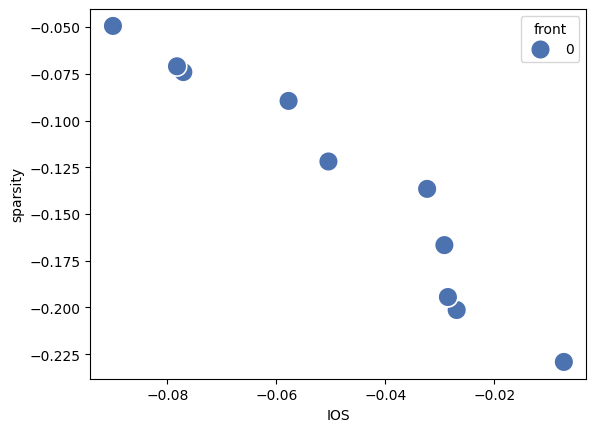

In [1144]:
g = sns.scatterplot(data=filt_objective_fitness_df, x=objective_front[0], y=objective_front[1], hue="front", palette="deep", s=200)
plt.savefig(f'./experiments/results/paretofront_{dataset}_instance_{instance}_{objective_front}.png', dpi=600)

In [1133]:
ilocs = [0, len(filt_objective_fitness_df) // 4, len(filt_objective_fitness_df) // 2, len(filt_objective_fitness_df) // 1.33, -1]
# ilocs = [0, len(filt_objective_fitness_df) // 2, -1]
filt_objective_fitness_df = filt_objective_fitness_df.iloc[ilocs]
filt_objective_fitness_df = filt_objective_fitness_df.drop_duplicates()
index_to_plot = filt_objective_fitness_df["index"].values

In [1134]:
filt_objective_fitness_df

,index,adversarial,sparsity,NoS,IOS,front
4,4,0.582002,-0.229167,-0.343295,-0.007269,0
89,89,0.539705,-0.194444,-0.408248,-0.028537,0
19,19,0.429009,-0.136574,-0.333333,-0.032350,0
54,54,0.466604,-0.074074,-0.296380,-0.077074,0
1,1,0.375401,-0.049383,-0.280299,-0.089985,0


In [1135]:
def plot_front_cfs(x_orig, front_cfs, store=False):
    
    # Calculate auxiliary variables
    x_cfs = front_cfs
    length = x_orig.shape[0]
    n_channels = x_orig.shape[1]

    # Define outer grid
    grid_columns = len(front_cfs)
    grid_rows = math.ceil(len(x_cfs) / grid_columns)
    fig = plt.figure(figsize=(14, grid_rows*4))
    outer_grid = gridspec.GridSpec(grid_rows, grid_columns, wspace=0.2, hspace=0.2)

    # Iterate through outer grid plots
    for m, outer in enumerate(outer_grid):
        try:
            # Get change mask 
            x_cf = x_cfs[m]
            """# Get nuns used by the method depending on the name
            if "gknn" in method_name:
                nun_example = possible_nuns["gknn"]
            elif "iknn" in method_name:
                nun_example = possible_nuns["iknn"]
            else:
                raise ValueError('Not detected NUN finding procedure in name. Method name must contain "gknn" or "iknn"')"""
            # found_counterfactual_mask = (x_orig != x_cf.reshape(1, length, n_channels)).astype(int)
            proximity_values = np.abs(x_orig - x_cf.reshape(1, length, n_channels))
            found_counterfactual_mask = (proximity_values > np.abs(x_orig)/proximity_values*0.0001).astype(int)
            diff_mask = np.diff(found_counterfactual_mask, prepend=0, append=0, axis=1)
        except IndexError:
            break
    
        # Create inner grid
        inner_grid = gridspec.GridSpecFromSubplotSpec(n_channels, 1, wspace=0.1, hspace=0.1, subplot_spec=outer)
        sub_channel_axs = []
        for i in range(n_channels):
            ax = plt.Subplot(fig, inner_grid[i])
            # ax.plot(nun_example.reshape(1, length, n_channels)[:, :, i].flatten(), color='grey')
            ax.plot(x_cf.reshape(1, length, n_channels)[:, :, i].flatten(), color='red')
            ax.plot(x_orig.reshape(1, length, n_channels)[:, :, i].flatten(), color="#332288")
            ax.set_yticklabels([])
            ax.set_xticklabels([])
            ax.axis('off')
            # Set title if first channel
            if i == 0:
                ax.set_title(m)
            
            # Add fill to changes
            starts = np.clip( np.where(diff_mask[0, :, i].flatten() == 1)[0] - 1 , 0, length)
            ends = np.where(diff_mask[0, :, i].flatten() == -1)[0]
            # Iterate over the mask segments and fill them with red color
            for i in range(0, len(starts)):
                start_idx = starts[i]
                end_idx = ends[i]
                # plt.fill_between(comp_df.iloc[start_idx:end_idx].index, comp_df.min(), comp_df.max(), color='red', alpha=0.7)
                ax.axvspan(start_idx, end_idx, alpha=0.2, color='red')
            
            # Add ax to list of subplots
            fig.add_subplot(ax)
            sub_channel_axs.append(ax)

    # Plot figure
    """fig.legend(
        sub_channel_axs,     # The line objects
        labels=['x_cf', 'x_orig'],   # The labels for each line
        loc='upper right',
        prop={'size': 12}
    )"""
    plt.tight_layout()
    # plt.show()
    if store:
        plt.savefig(f'./experiments/results/paretofront_cfs_{dataset}_instance_{instance}_{objective_front}.png', dpi=600)



C:\Users\mrefoyo\AppData\Local\Temp\ipykernel_1220\232148653.py:28: RuntimeWarning: divide by zero encountered in divide
  found_counterfactual_mask = (proximity_values > np.abs(x_orig)/proximity_values*0.0001).astype(int)
C:\Users\mrefoyo\AppData\Local\Temp\ipykernel_1220\232148653.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


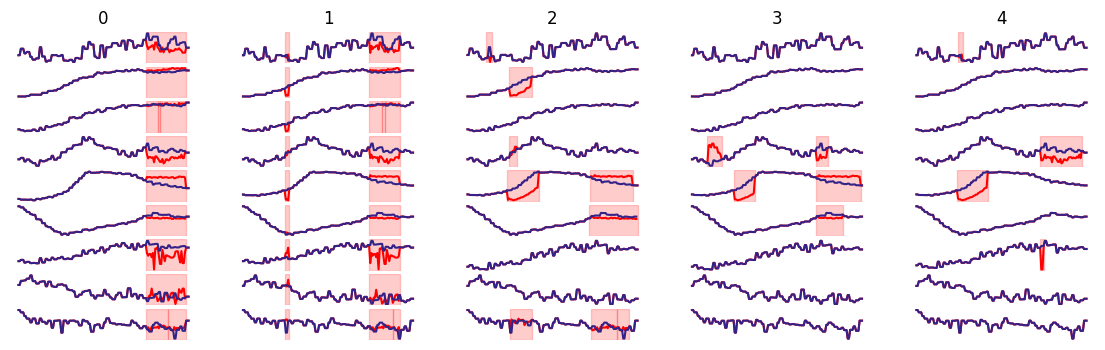

In [1137]:
front_cfs = counterfactuals_i[index_to_plot]
plot_front_cfs(x_orig_i, front_cfs, store=True)

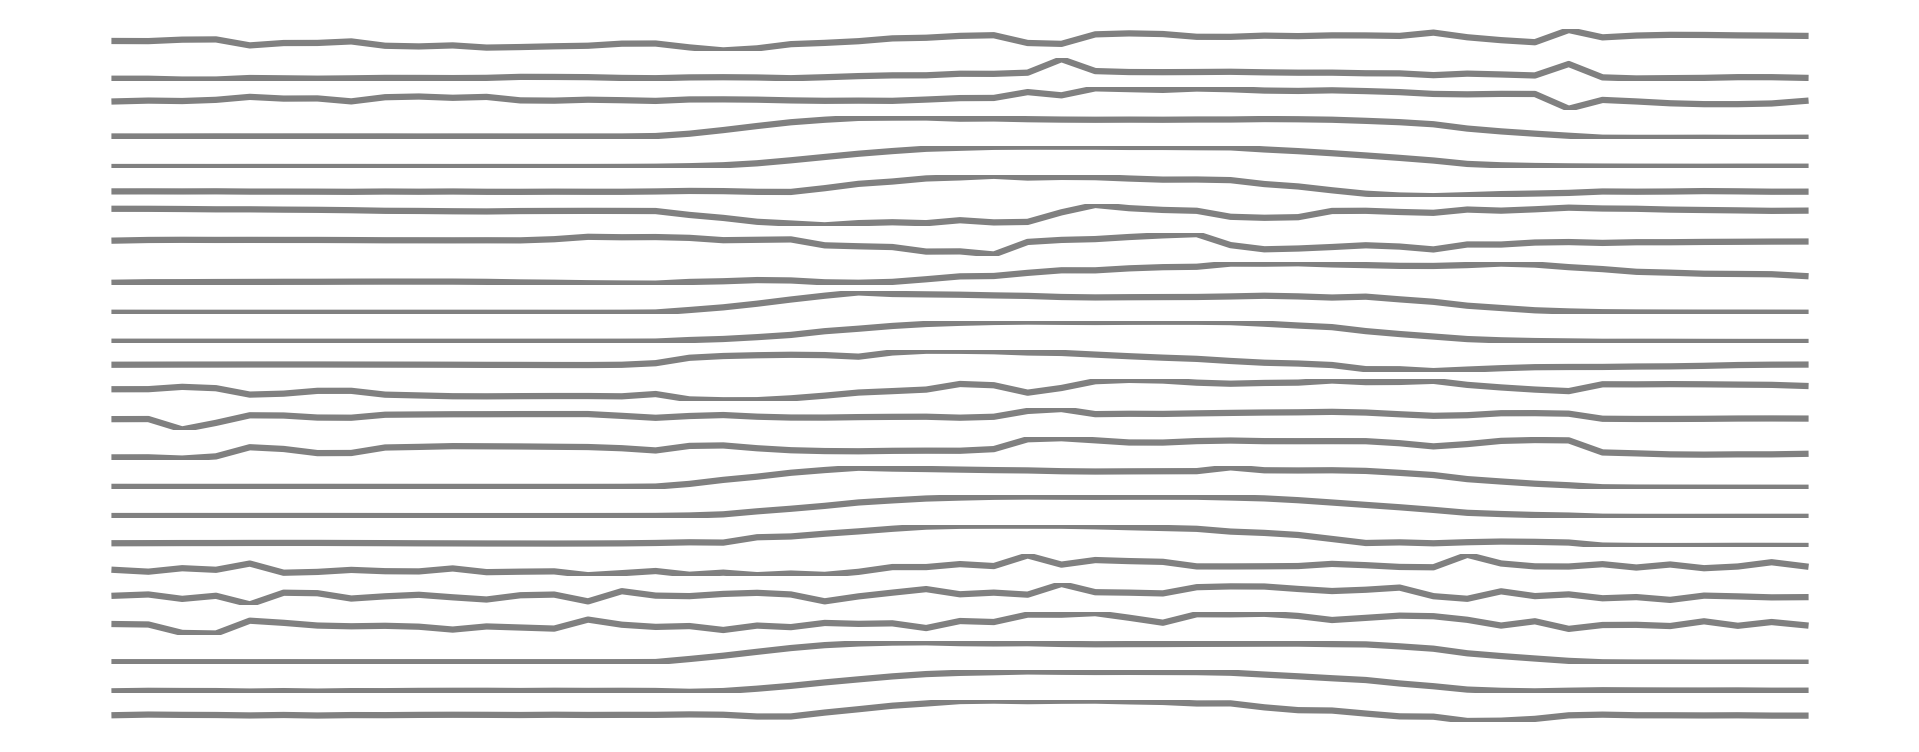

In [920]:
length = x_orig_i.shape[0]
n_channels = x_orig_i.shape[1]

fig = plt.figure(figsize=(8, 3), dpi=300)
grid = gridspec.GridSpec(n_channels, 1, wspace=0.2, hspace=0.3)
for i in range(n_channels):
    ax = plt.Subplot(fig, grid[i])
    # ax.plot(nun_example.reshape(1, length, n_channels)[:, :, i].flatten(), color='grey')
    ax.plot(nun_i.reshape(1, length, n_channels)[:, :, i].flatten(), color="grey")
    ax.set_yticklabels([])
    ax.axis('off')
    fig.add_subplot(ax)
plt.show()

C:\Users\mrefoyo\AppData\Local\Temp\ipykernel_13368\2757957680.py:8: RuntimeWarning: divide by zero encountered in divide
  found_counterfactual_mask = (proximity_values > np.abs(x_orig_i)/proximity_values*0.0001).astype(int)


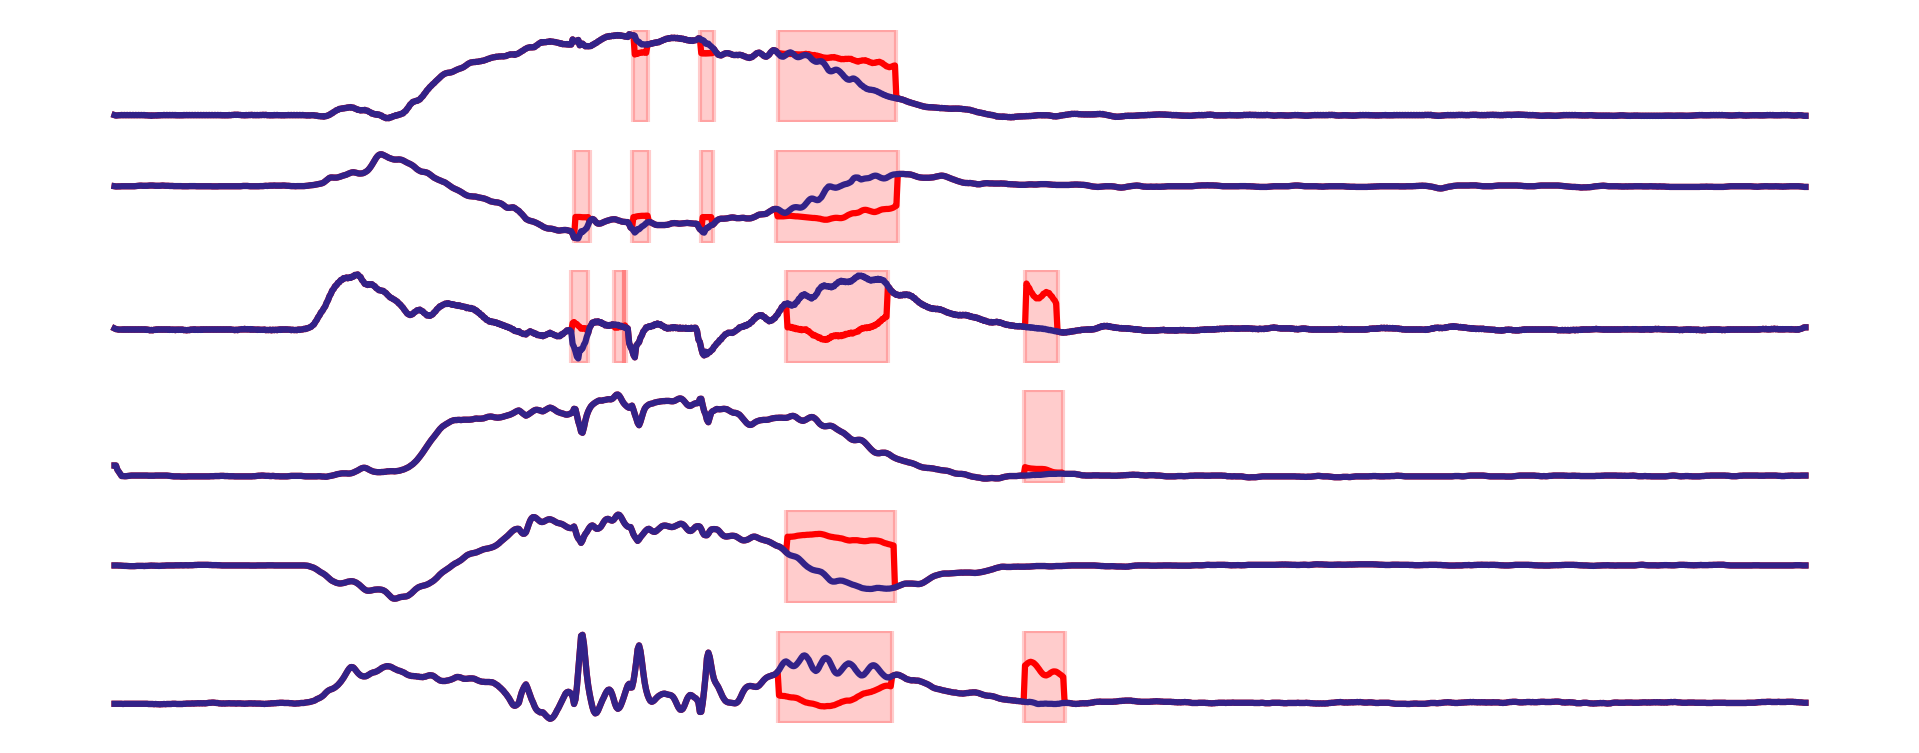

In [814]:
length = x_orig_i.shape[0]
n_channels = x_orig_i.shape[1]

x_cf = front_cfs[2]


proximity_values = np.abs(x_orig_i - x_cf.reshape(1, length, n_channels))
found_counterfactual_mask = (proximity_values > np.abs(x_orig_i)/proximity_values*0.0001).astype(int)
diff_mask = np.diff(found_counterfactual_mask, prepend=0, append=0, axis=1)



fig = plt.figure(figsize=(8, 3), dpi=300)
grid = gridspec.GridSpec(n_channels, 1, wspace=0.2, hspace=0.3)
for i in range(n_channels):
    ax = plt.Subplot(fig, grid[i])
    # ax.plot(nun_example.reshape(1, length, n_channels)[:, :, i].flatten(), color='grey')
    ax.plot(x_cf.reshape(1, length, n_channels)[:, :, i].flatten(), color='red')
    ax.plot(x_orig_i.reshape(1, length, n_channels)[:, :, i].flatten(), color="#332288")
    ax.set_yticklabels([])
    
    # Add fill to changes
    starts = np.clip( np.where(diff_mask[0, :, i].flatten() == 1)[0] - 1 , 0, length)
    ends = np.where(diff_mask[0, :, i].flatten() == -1)[0]
    # Iterate over the mask segments and fill them with red color
    for i in range(0, len(starts)):
        start_idx = starts[i]
        end_idx = ends[i]
        # plt.fill_between(comp_df.iloc[start_idx:end_idx].index, comp_df.min(), comp_df.max(), color='red', alpha=0.7)
        ax.axvspan(start_idx, end_idx, alpha=0.2, color='red')
    
    # Add ax to list of subplots
    ax.axis('off')
    fig.add_subplot(ax)
plt.show()